In [3]:
import numpy as np
import os
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

original composition below

In [4]:
A_H_Array = []

with open("/Users/evely/Group-Studies---Exoplanets/Data/40_planets_under_1000K05.02_15-55.csv", newline="") as PlanetaryParametersFile: 
    reader = csv.reader(PlanetaryParametersFile)
    header = next(reader)
    data = []
    planetNames = []
    for row in reader:
        row = [item.strip() for item in row]
        if len(row) == 0:
            continue
        name, *nums = row
        conv = [float(item) if item != "" else np.nan for item in nums]
        data.append(conv)
        planetNames.append(name)
    planetaryParameters = np.array(data, dtype=float)

rowCount= 0
while rowCount < len(planetaryParameters):
    PName = planetNames[rowCount]                                   ## planet name   
    print(f"---Analysing Planet: {PName} ----")
#    print(f"Star Manitude: {planetaryParameters[rowCount][20]}")

    ## CHANGE INDEXES IF NEED BE ##
    
    l_press = np.logspace(-3,7,100, base = 10)
    AH_press = np.zeros(len(l_press))                                 ## Array for holidng the scale heights as measured with different cloud pressures
    pval = np.zeros(len(l_press))
    for count_p in range(len(l_press)):

        Rp = planetaryParameters[rowCount][3]                           ## planet radius in units of Earth radii
        Mp = planetaryParameters[rowCount][2]                           ## planet mass in units of Earth masses
        Tp = planetaryParameters[rowCount][39]                          ## planet temperature in K
        mu = 4.88                                                       ## mean molecular weight in atomic mass units
        Pcloud = l_press[count_p]                                   ## pressure at top of cloud deck in bar 
        Pref = 0.01                                                     ## pressure at which mass, radius and gravity are defined in bar
        Rs = planetaryParameters[rowCount][14]                          ## stellar radius in units of Solar radii     
        Rp *= const.R_earth.value                                       ## Convert Rp from units of R_Earth to m
        Rs *= const.R_sun.value                                         ## Convert Rs from units of R_Sun to m
        #Pcloud *= 1.0e5                                                 ## Convert Pcloud from bar to Pa
        Pref *= 1.0e5                                                   ## Convert Pref from bar to Pa
        mu *= sc.u                                                      ## Convert mu from atomic mass units to kg#

        
        xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
        lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
        P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
        T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

        # Read in CO2 cross section data
        xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
        lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
        P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
        T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

        # Read in CH4 cross section data
        xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
        lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
        P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
        T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

        #read in CO cross section data
        xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
        lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
        P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
        T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

        # H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
        xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
        lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

        xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
        lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')


    #    print('shape of xsec:', xsec_h2o.shape)
    #    print('shape of lam:', lam_h2o.shape)
    #    print('shape of P:', P_h2o.shape)
    #    print('shape of P:', T_h2o.shape)

        P = np.logspace(2.0,-9,200) * 1.0e5
        T = Tp*np.ones_like(P)
        n = P/(sc.k*T)
        rho = mu*n
        gp = (sc.G * Mp * const.M_earth.value) / (Rp)**2
        r = np.zeros_like(P)
        g = np.zeros_like(P)
        i_Rp = np.argmin(np.abs(P-Pref))
        r[i_Rp] = Rp
        g[i_Rp] = gp

        # First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
        logX = dict()
        logX['h2o'] = -1.1
        logX['ch4'] = -1.74
        logX['co'] = -2.0
        logX['co2'] = -1.7
        #original

        ## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
        mmw = dict()
        mmw['h2o'] = 18.0
        mmw['ch4'] = 16.0
        mmw['co'] = 28.0
        mmw['co2'] = 44.0
        mmw['h2'] = 2.0
        mmw['he'] = 4.0

        # Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
        # Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
        # Then X_H2 + X_He = 1 - X_rest

        X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
        X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
        X_He = 0.17 * X_H2

        # Now let's add H2 and He to the logX dictionary

        logX['h2'] = np.log10(X_H2)
        logX['he'] = np.log10(X_He)

        for i in range(i_Rp + 1, len(P)):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
            r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

        for i in range(i_Rp-1, -1, -1):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
            r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

        # With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
        mu = 0.0
        for mol in logX.keys():
            mu += np.power(10.0,logX[mol])*mmw[mol]

    #    print("The mean molecular weight is:", mu)

        xsec_dict = dict()
        lam_dict = dict()
        P_dict = dict()
        T_dict = dict()



        lam = np.linspace(0.61,5.0,1000)

        log_xsec_dict = dict()

        lamlam, PP = np.meshgrid(lam, P, indexing="ij")

        # ---- H2O ----
        interp_h2o = RegularGridInterpolator(
            (lam_h2o, P_h2o, T_h2o),
            xsec_h2o,
            method='linear', bounds_error=False,
            fill_value=None)
        log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

        # ---- CO2 ----
        interp_co2 = RegularGridInterpolator(
            (lam_co2, P_co2, T_co2),
            xsec_co2,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

        # ---- CH4 ----
        interp_ch4 = RegularGridInterpolator(
            (lam_ch4, P_ch4, T_ch4),
            xsec_ch4,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

        interp_co2 = RegularGridInterpolator(
            (lam_co, P_co, T_co),
            xsec_co,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co'] = interp_co2((lamlam, PP, T[0]))

        log_cia_dict = dict()
        log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
        log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

        sum_nsigma = np.zeros((len(lam), len(P)))
        for mol in log_xsec_dict.keys():
            sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

        integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
        integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

        exptau = np.zeros((len(P),len(lam)))
        transit_depth = np.zeros((len(lam))) 

        # Compute the total optical depth at each impact parameter and wavelength #

        opacity = sum_nsigma #(kappa+sigma)
        # For each layer of atmosphere

        for i in range(len(r)-1):

            s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
            ds = s_tot[1:]-s_tot[:-1]

            tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

            # If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
            if P[i] > Pcloud:
                tau_tot += 1000.0

            # We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
            exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


        # Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
        for i in range(len(r)-1):

            # Rays travelling through atmosphere above Rp
            if (r[i] >= Rp):
                integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

            # Rays travelling through atmosphere below Rp
            if (r[i] < Rp):
                integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

        # Compute effective transit depth (transmission spectrum) #
        transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)


#         plt.plot(lam,transit_depth*1e6) #convert transit_depth into units of ppm
#         plt.xlabel('Wavelength (microns)')
#         plt.ylabel('Transit Depth (ppm)')
#         plt.title(f'Transmission Spectrum of {PName}')
#         plt.xlim([2.5,5.0])
#         plt.show()

        np.savetxt(f'planet_spectrum_{PName}.txt', np.column_stack((lam, transit_depth)), header='Wavelength(micron)   Transit_Depth(rp^2/r*^2)', fmt='%10.6f')

        #A_H_Array = []

        # 1. Load your spectrum data
        loaded_spec = np.loadtxt("planet_spectrum_{PName}.txt".format(PName=PName))
        lam_data = loaded_spec[:, 0]
        depth_data = loaded_spec[:, 1]

        # 2. Find Left Trough (4-4.3 um)
        left_mask = (lam_data >= 1.24) & (lam_data <= 1.29)   #H2O feature
        #left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
        # Extract values in that window
        left_depth_values = depth_data[left_mask]
        left_lam_values = lam_data[left_mask]
        # Take averages
        left_val = np.mean(left_depth_values)
        left_lam_target = np.mean(left_lam_values)

        # 4. Identify the Peak region between those two troughs
        #peak_mask = (lam_data >= left_lam_target) & (lam_data <= right_lam_target)
        peak_mask = (lam_data >= 1.38) & (lam_data <= 1.41)   # H2O feature
        # Extract values in that window
        peak_region_depths = depth_data[peak_mask]
        peak_x_values = lam_data[peak_mask]

        # 5. Calculate Height and the Scatter Error
        peak_val = np.mean(peak_region_depths)
        peak_x_value = np.mean(peak_x_values)
        feature_height_ratio = (peak_val - left_val)
        feature_height_ppm = (peak_val - left_val) * 1e6
        #feature_height_ppm_Array.append(feature_height_ppm)

        # The "Error" is the standard deviation of the points in the peak region
        # This represents the local variation/noise in your model
        peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6

    #    print(f"--- {PName} ---")
    #    print(f"Feature Height: {feature_height_ppm:.2f} ppm")
    #    print(f"Model Scatter (Error): {peak_scatter_error_ppm:.2f} ppm")

        scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)
    #    print('Scale Height is,', scale_height)

        A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)
        A_H_Array.append(A_H)
        AH_press[count_p] = A_H
        pval[count_p] = Pcloud
     #   print('A_H =', A_H)
        
    #print(AH_press)

    rowCount += 100

A_H_original = A_H_Array.copy()
pval_original = pval.copy()

---Analysing Planet: GJ 1214 b ----


changing H2O only

In [5]:
A_H_Array = []

with open("/Users/evely/Group-Studies---Exoplanets/Data/40_planets_under_1000K05.02_15-55.csv", newline="") as PlanetaryParametersFile: 
    reader = csv.reader(PlanetaryParametersFile)
    header = next(reader)
    data = []
    planetNames = []
    for row in reader:
        row = [item.strip() for item in row]
        if len(row) == 0:
            continue
        name, *nums = row
        conv = [float(item) if item != "" else np.nan for item in nums]
        data.append(conv)
        planetNames.append(name)
    planetaryParameters = np.array(data, dtype=float)

rowCount= 0
while rowCount < len(planetaryParameters):
    PName = planetNames[rowCount]                                   ## planet name   
    print(f"---Analysing Planet: {PName} ----")
#    print(f"Star Manitude: {planetaryParameters[rowCount][20]}")

    ## CHANGE INDEXES IF NEED BE ##
    
    l_press = np.logspace(-3,7,100, base = 10)
    AH_press = np.zeros(len(l_press))                                 ## Array for holidng the scale heights as measured with different cloud pressures
    pval = np.zeros(len(l_press))
    for count_p in range(len(l_press)):

        Rp = planetaryParameters[rowCount][3]                           ## planet radius in units of Earth radii
        Mp = planetaryParameters[rowCount][2]                           ## planet mass in units of Earth masses
        Tp = planetaryParameters[rowCount][39]                          ## planet temperature in K
        mu = 4.88                                                       ## mean molecular weight in atomic mass units
        Pcloud = l_press[count_p]                                   ## pressure at top of cloud deck in bar 
        Pref = 0.01                                                     ## pressure at which mass, radius and gravity are defined in bar
        Rs = planetaryParameters[rowCount][14]                          ## stellar radius in units of Solar radii     
        Rp *= const.R_earth.value                                       ## Convert Rp from units of R_Earth to m
        Rs *= const.R_sun.value                                         ## Convert Rs from units of R_Sun to m
        #Pcloud *= 1.0e5                                                 ## Convert Pcloud from bar to Pa
        Pref *= 1.0e5                                                   ## Convert Pref from bar to Pa
        mu *= sc.u                                                      ## Convert mu from atomic mass units to kg#

        
        xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
        lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
        P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
        T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

        # Read in CO2 cross section data
        xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
        lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
        P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
        T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

        # Read in CH4 cross section data
        xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
        lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
        P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
        T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

        #read in CO cross section data
        xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
        lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
        P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
        T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

        # H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
        xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
        lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

        xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
        lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')


    #    print('shape of xsec:', xsec_h2o.shape)
    #    print('shape of lam:', lam_h2o.shape)
    #    print('shape of P:', P_h2o.shape)
    #    print('shape of P:', T_h2o.shape)

        P = np.logspace(2.0,-9,200) * 1.0e5
        T = Tp*np.ones_like(P)
        n = P/(sc.k*T)
        rho = mu*n
        gp = (sc.G * Mp * const.M_earth.value) / (Rp)**2
        r = np.zeros_like(P)
        g = np.zeros_like(P)
        i_Rp = np.argmin(np.abs(P-Pref))
        r[i_Rp] = Rp
        g[i_Rp] = gp

        # First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
        logX = dict()
        logX['h2o'] = -0.1
        logX['ch4'] = -1.74
        logX['co'] = -2.0
        logX['co2'] = -1.7
        #changing H2O only

        ## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
        mmw = dict()
        mmw['h2o'] = 18.0
        mmw['ch4'] = 16.0
        mmw['co'] = 28.0
        mmw['co2'] = 44.0
        mmw['h2'] = 2.0
        mmw['he'] = 4.0

        # Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
        # Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
        # Then X_H2 + X_He = 1 - X_rest

        X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
        X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
        X_He = 0.17 * X_H2

        # Now let's add H2 and He to the logX dictionary

        logX['h2'] = np.log10(X_H2)
        logX['he'] = np.log10(X_He)

        for i in range(i_Rp + 1, len(P)):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
            r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

        for i in range(i_Rp-1, -1, -1):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
            r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

        # With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
        mu = 0.0
        for mol in logX.keys():
            mu += np.power(10.0,logX[mol])*mmw[mol]

    #    print("The mean molecular weight is:", mu)

        xsec_dict = dict()
        lam_dict = dict()
        P_dict = dict()
        T_dict = dict()



        lam = np.linspace(0.61,5.0,1000)

        log_xsec_dict = dict()

        lamlam, PP = np.meshgrid(lam, P, indexing="ij")

        # ---- H2O ----
        interp_h2o = RegularGridInterpolator(
            (lam_h2o, P_h2o, T_h2o),
            xsec_h2o,
            method='linear', bounds_error=False,
            fill_value=None)
        log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

        # ---- CO2 ----
        interp_co2 = RegularGridInterpolator(
            (lam_co2, P_co2, T_co2),
            xsec_co2,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

        # ---- CH4 ----
        interp_ch4 = RegularGridInterpolator(
            (lam_ch4, P_ch4, T_ch4),
            xsec_ch4,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

        interp_co2 = RegularGridInterpolator(
            (lam_co, P_co, T_co),
            xsec_co,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co'] = interp_co2((lamlam, PP, T[0]))

        log_cia_dict = dict()
        log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
        log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

        sum_nsigma = np.zeros((len(lam), len(P)))
        for mol in log_xsec_dict.keys():
            sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

        integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
        integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

        exptau = np.zeros((len(P),len(lam)))
        transit_depth = np.zeros((len(lam))) 

        # Compute the total optical depth at each impact parameter and wavelength #

        opacity = sum_nsigma #(kappa+sigma)
        # For each layer of atmosphere

        for i in range(len(r)-1):

            s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
            ds = s_tot[1:]-s_tot[:-1]

            tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

            # If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
            if P[i] > Pcloud:
                tau_tot += 1000.0

            # We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
            exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


        # Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
        for i in range(len(r)-1):

            # Rays travelling through atmosphere above Rp
            if (r[i] >= Rp):
                integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

            # Rays travelling through atmosphere below Rp
            if (r[i] < Rp):
                integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

        # Compute effective transit depth (transmission spectrum) #
        transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)


#         plt.plot(lam,transit_depth*1e6) #convert transit_depth into units of ppm
#         plt.xlabel('Wavelength (microns)')
#         plt.ylabel('Transit Depth (ppm)')
#         plt.title(f'Transmission Spectrum of {PName}')
#         plt.xlim([2.5,5.0])
#         plt.show()

        np.savetxt(f'planet_spectrum_{PName}.txt', np.column_stack((lam, transit_depth)), header='Wavelength(micron)   Transit_Depth(rp^2/r*^2)', fmt='%10.6f')

        #A_H_Array = []

        # 1. Load your spectrum data
        loaded_spec = np.loadtxt("planet_spectrum_{PName}.txt".format(PName=PName))
        lam_data = loaded_spec[:, 0]
        depth_data = loaded_spec[:, 1]

        # 2. Find Left Trough (4-4.3 um)
        left_mask = (lam_data >= 1.24) & (lam_data <= 1.29)   #H2O feature
        #left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
        # Extract values in that window
        left_depth_values = depth_data[left_mask]
        left_lam_values = lam_data[left_mask]
        # Take averages
        left_val = np.mean(left_depth_values)
        left_lam_target = np.mean(left_lam_values)

        # 4. Identify the Peak region between those two troughs
        #peak_mask = (lam_data >= left_lam_target) & (lam_data <= right_lam_target)
        peak_mask = (lam_data >= 1.38) & (lam_data <= 1.41)   # H2O feature
        # Extract values in that window
        peak_region_depths = depth_data[peak_mask]
        peak_x_values = lam_data[peak_mask]

        # 5. Calculate Height and the Scatter Error
        peak_val = np.mean(peak_region_depths)
        peak_x_value = np.mean(peak_x_values)
        feature_height_ratio = (peak_val - left_val)
        feature_height_ppm = (peak_val - left_val) * 1e6
        #feature_height_ppm_Array.append(feature_height_ppm)

        # The "Error" is the standard deviation of the points in the peak region
        # This represents the local variation/noise in your model
        peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6

    #    print(f"--- {PName} ---")
    #    print(f"Feature Height: {feature_height_ppm:.2f} ppm")
    #    print(f"Model Scatter (Error): {peak_scatter_error_ppm:.2f} ppm")

        scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)
    #    print('Scale Height is,', scale_height)

        A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)
        A_H_Array.append(A_H)
        AH_press[count_p] = A_H
        pval[count_p] = Pcloud
     #   print('A_H =', A_H)
        
    #print(AH_press)

    rowCount += 100

A_H_H2O = A_H_Array.copy()
pval_H2O = pval.copy()

---Analysing Planet: GJ 1214 b ----


changing CH4 only

In [6]:
A_H_Array = []

with open("/Users/evely/Group-Studies---Exoplanets/Data/40_planets_under_1000K05.02_15-55.csv", newline="") as PlanetaryParametersFile: 
    reader = csv.reader(PlanetaryParametersFile)
    header = next(reader)
    data = []
    planetNames = []
    for row in reader:
        row = [item.strip() for item in row]
        if len(row) == 0:
            continue
        name, *nums = row
        conv = [float(item) if item != "" else np.nan for item in nums]
        data.append(conv)
        planetNames.append(name)
    planetaryParameters = np.array(data, dtype=float)

rowCount= 0
while rowCount < len(planetaryParameters):
    PName = planetNames[rowCount]                                   ## planet name   
    print(f"---Analysing Planet: {PName} ----")
#    print(f"Star Manitude: {planetaryParameters[rowCount][20]}")

    ## CHANGE INDEXES IF NEED BE ##
    
    l_press = np.logspace(-3,7,100, base = 10)
    AH_press = np.zeros(len(l_press))                                 ## Array for holidng the scale heights as measured with different cloud pressures
    pval = np.zeros(len(l_press))
    for count_p in range(len(l_press)):

        Rp = planetaryParameters[rowCount][3]                           ## planet radius in units of Earth radii
        Mp = planetaryParameters[rowCount][2]                           ## planet mass in units of Earth masses
        Tp = planetaryParameters[rowCount][39]                          ## planet temperature in K
        mu = 4.88                                                       ## mean molecular weight in atomic mass units
        Pcloud = l_press[count_p]                                   ## pressure at top of cloud deck in bar 
        Pref = 0.01                                                     ## pressure at which mass, radius and gravity are defined in bar
        Rs = planetaryParameters[rowCount][14]                          ## stellar radius in units of Solar radii     
        Rp *= const.R_earth.value                                       ## Convert Rp from units of R_Earth to m
        Rs *= const.R_sun.value                                         ## Convert Rs from units of R_Sun to m
        #Pcloud *= 1.0e5                                                 ## Convert Pcloud from bar to Pa
        Pref *= 1.0e5                                                   ## Convert Pref from bar to Pa
        mu *= sc.u                                                      ## Convert mu from atomic mass units to kg#

        
        xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
        lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
        P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
        T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

        # Read in CO2 cross section data
        xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
        lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
        P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
        T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

        # Read in CH4 cross section data
        xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
        lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
        P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
        T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

        #read in CO cross section data
        xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
        lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
        P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
        T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

        # H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
        xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
        lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

        xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
        lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')


    #    print('shape of xsec:', xsec_h2o.shape)
    #    print('shape of lam:', lam_h2o.shape)
    #    print('shape of P:', P_h2o.shape)
    #    print('shape of P:', T_h2o.shape)

        P = np.logspace(2.0,-9,200) * 1.0e5
        T = Tp*np.ones_like(P)
        n = P/(sc.k*T)
        rho = mu*n
        gp = (sc.G * Mp * const.M_earth.value) / (Rp)**2
        r = np.zeros_like(P)
        g = np.zeros_like(P)
        i_Rp = np.argmin(np.abs(P-Pref))
        r[i_Rp] = Rp
        g[i_Rp] = gp

        # First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
        logX = dict()
        logX['h2o'] = -1.1
        logX['ch4'] = -0.74
        logX['co'] = -2.0
        logX['co2'] = -1.7
        #CH4 changed only

        ## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
        mmw = dict()
        mmw['h2o'] = 18.0
        mmw['ch4'] = 16.0
        mmw['co'] = 28.0
        mmw['co2'] = 44.0
        mmw['h2'] = 2.0
        mmw['he'] = 4.0

        # Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
        # Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
        # Then X_H2 + X_He = 1 - X_rest

        X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
        X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
        X_He = 0.17 * X_H2

        # Now let's add H2 and He to the logX dictionary

        logX['h2'] = np.log10(X_H2)
        logX['he'] = np.log10(X_He)

        for i in range(i_Rp + 1, len(P)):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
            r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

        for i in range(i_Rp-1, -1, -1):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
            r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

        # With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
        mu = 0.0
        for mol in logX.keys():
            mu += np.power(10.0,logX[mol])*mmw[mol]

    #    print("The mean molecular weight is:", mu)

        xsec_dict = dict()
        lam_dict = dict()
        P_dict = dict()
        T_dict = dict()



        lam = np.linspace(0.61,5.0,1000)

        log_xsec_dict = dict()

        lamlam, PP = np.meshgrid(lam, P, indexing="ij")

        # ---- H2O ----
        interp_h2o = RegularGridInterpolator(
            (lam_h2o, P_h2o, T_h2o),
            xsec_h2o,
            method='linear', bounds_error=False,
            fill_value=None)
        log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

        # ---- CO2 ----
        interp_co2 = RegularGridInterpolator(
            (lam_co2, P_co2, T_co2),
            xsec_co2,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

        # ---- CH4 ----
        interp_ch4 = RegularGridInterpolator(
            (lam_ch4, P_ch4, T_ch4),
            xsec_ch4,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

        interp_co2 = RegularGridInterpolator(
            (lam_co, P_co, T_co),
            xsec_co,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co'] = interp_co2((lamlam, PP, T[0]))

        log_cia_dict = dict()
        log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
        log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

        sum_nsigma = np.zeros((len(lam), len(P)))
        for mol in log_xsec_dict.keys():
            sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

        integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
        integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

        exptau = np.zeros((len(P),len(lam)))
        transit_depth = np.zeros((len(lam))) 

        # Compute the total optical depth at each impact parameter and wavelength #

        opacity = sum_nsigma #(kappa+sigma)
        # For each layer of atmosphere

        for i in range(len(r)-1):

            s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
            ds = s_tot[1:]-s_tot[:-1]

            tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

            # If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
            if P[i] > Pcloud:
                tau_tot += 1000.0

            # We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
            exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


        # Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
        for i in range(len(r)-1):

            # Rays travelling through atmosphere above Rp
            if (r[i] >= Rp):
                integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

            # Rays travelling through atmosphere below Rp
            if (r[i] < Rp):
                integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

        # Compute effective transit depth (transmission spectrum) #
        transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)


#         plt.plot(lam,transit_depth*1e6) #convert transit_depth into units of ppm
#         plt.xlabel('Wavelength (microns)')
#         plt.ylabel('Transit Depth (ppm)')
#         plt.title(f'Transmission Spectrum of {PName}')
#         plt.xlim([2.5,5.0])
#         plt.show()

        np.savetxt(f'planet_spectrum_{PName}.txt', np.column_stack((lam, transit_depth)), header='Wavelength(micron)   Transit_Depth(rp^2/r*^2)', fmt='%10.6f')

        #A_H_Array = []

        # 1. Load your spectrum data
        loaded_spec = np.loadtxt("planet_spectrum_{PName}.txt".format(PName=PName))
        lam_data = loaded_spec[:, 0]
        depth_data = loaded_spec[:, 1]

        # 2. Find Left Trough (4-4.3 um)
        left_mask = (lam_data >= 1.24) & (lam_data <= 1.29)   #H2O feature
        #left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
        # Extract values in that window
        left_depth_values = depth_data[left_mask]
        left_lam_values = lam_data[left_mask]
        # Take averages
        left_val = np.mean(left_depth_values)
        left_lam_target = np.mean(left_lam_values)

        # 4. Identify the Peak region between those two troughs
        #peak_mask = (lam_data >= left_lam_target) & (lam_data <= right_lam_target)
        peak_mask = (lam_data >= 1.38) & (lam_data <= 1.41)   # H2O feature
        # Extract values in that window
        peak_region_depths = depth_data[peak_mask]
        peak_x_values = lam_data[peak_mask]

        # 5. Calculate Height and the Scatter Error
        peak_val = np.mean(peak_region_depths)
        peak_x_value = np.mean(peak_x_values)
        feature_height_ratio = (peak_val - left_val)
        feature_height_ppm = (peak_val - left_val) * 1e6
        #feature_height_ppm_Array.append(feature_height_ppm)

        # The "Error" is the standard deviation of the points in the peak region
        # This represents the local variation/noise in your model
        peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6

    #    print(f"--- {PName} ---")
    #    print(f"Feature Height: {feature_height_ppm:.2f} ppm")
    #    print(f"Model Scatter (Error): {peak_scatter_error_ppm:.2f} ppm")

        scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)
    #    print('Scale Height is,', scale_height)

        A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)
        A_H_Array.append(A_H)
        AH_press[count_p] = A_H
        pval[count_p] = Pcloud
     #   print('A_H =', A_H)
        
    #print(AH_press)

    rowCount += 100

A_H_CH4 = A_H_Array.copy()
pval_CH4 = pval.copy()

---Analysing Planet: GJ 1214 b ----


changing CO only

In [7]:
A_H_Array = []

with open("/Users/evely/Group-Studies---Exoplanets/Data/40_planets_under_1000K05.02_15-55.csv", newline="") as PlanetaryParametersFile: 
    reader = csv.reader(PlanetaryParametersFile)
    header = next(reader)
    data = []
    planetNames = []
    for row in reader:
        row = [item.strip() for item in row]
        if len(row) == 0:
            continue
        name, *nums = row
        conv = [float(item) if item != "" else np.nan for item in nums]
        data.append(conv)
        planetNames.append(name)
    planetaryParameters = np.array(data, dtype=float)

rowCount= 0
while rowCount < len(planetaryParameters):
    PName = planetNames[rowCount]                                   ## planet name   
    print(f"---Analysing Planet: {PName} ----")
#    print(f"Star Manitude: {planetaryParameters[rowCount][20]}")

    ## CHANGE INDEXES IF NEED BE ##
    
    l_press = np.logspace(-3,7,100, base = 10)
    AH_press = np.zeros(len(l_press))                                 ## Array for holidng the scale heights as measured with different cloud pressures
    pval = np.zeros(len(l_press))
    for count_p in range(len(l_press)):

        Rp = planetaryParameters[rowCount][3]                           ## planet radius in units of Earth radii
        Mp = planetaryParameters[rowCount][2]                           ## planet mass in units of Earth masses
        Tp = planetaryParameters[rowCount][39]                          ## planet temperature in K
        mu = 4.88                                                       ## mean molecular weight in atomic mass units
        Pcloud = l_press[count_p]                                   ## pressure at top of cloud deck in bar 
        Pref = 0.01                                                     ## pressure at which mass, radius and gravity are defined in bar
        Rs = planetaryParameters[rowCount][14]                          ## stellar radius in units of Solar radii     
        Rp *= const.R_earth.value                                       ## Convert Rp from units of R_Earth to m
        Rs *= const.R_sun.value                                         ## Convert Rs from units of R_Sun to m
        #Pcloud *= 1.0e5                                                 ## Convert Pcloud from bar to Pa
        Pref *= 1.0e5                                                   ## Convert Pref from bar to Pa
        mu *= sc.u                                                      ## Convert mu from atomic mass units to kg#

        
        xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
        lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
        P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
        T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

        # Read in CO2 cross section data
        xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
        lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
        P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
        T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

        # Read in CH4 cross section data
        xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
        lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
        P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
        T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

        #read in CO cross section data
        xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
        lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
        P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
        T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

        # H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
        xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
        lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

        xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
        lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')


    #    print('shape of xsec:', xsec_h2o.shape)
    #    print('shape of lam:', lam_h2o.shape)
    #    print('shape of P:', P_h2o.shape)
    #    print('shape of P:', T_h2o.shape)

        P = np.logspace(2.0,-9,200) * 1.0e5
        T = Tp*np.ones_like(P)
        n = P/(sc.k*T)
        rho = mu*n
        gp = (sc.G * Mp * const.M_earth.value) / (Rp)**2
        r = np.zeros_like(P)
        g = np.zeros_like(P)
        i_Rp = np.argmin(np.abs(P-Pref))
        r[i_Rp] = Rp
        g[i_Rp] = gp

        # First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
        logX = dict()
        logX['h2o'] = -1.1
        logX['ch4'] = -1.74
        logX['co'] = -1.0
        logX['co2'] = -1.7
        #CO changed only

        ## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
        mmw = dict()
        mmw['h2o'] = 18.0
        mmw['ch4'] = 16.0
        mmw['co'] = 28.0
        mmw['co2'] = 44.0
        mmw['h2'] = 2.0
        mmw['he'] = 4.0

        # Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
        # Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
        # Then X_H2 + X_He = 1 - X_rest

        X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
        X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
        X_He = 0.17 * X_H2

        # Now let's add H2 and He to the logX dictionary

        logX['h2'] = np.log10(X_H2)
        logX['he'] = np.log10(X_He)

        for i in range(i_Rp + 1, len(P)):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
            r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

        for i in range(i_Rp-1, -1, -1):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
            r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

        # With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
        mu = 0.0
        for mol in logX.keys():
            mu += np.power(10.0,logX[mol])*mmw[mol]

    #    print("The mean molecular weight is:", mu)

        xsec_dict = dict()
        lam_dict = dict()
        P_dict = dict()
        T_dict = dict()



        lam = np.linspace(0.61,5.0,1000)

        log_xsec_dict = dict()

        lamlam, PP = np.meshgrid(lam, P, indexing="ij")

        # ---- H2O ----
        interp_h2o = RegularGridInterpolator(
            (lam_h2o, P_h2o, T_h2o),
            xsec_h2o,
            method='linear', bounds_error=False,
            fill_value=None)
        log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

        # ---- CO2 ----
        interp_co2 = RegularGridInterpolator(
            (lam_co2, P_co2, T_co2),
            xsec_co2,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

        # ---- CH4 ----
        interp_ch4 = RegularGridInterpolator(
            (lam_ch4, P_ch4, T_ch4),
            xsec_ch4,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

        interp_co2 = RegularGridInterpolator(
            (lam_co, P_co, T_co),
            xsec_co,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co'] = interp_co2((lamlam, PP, T[0]))

        log_cia_dict = dict()
        log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
        log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

        sum_nsigma = np.zeros((len(lam), len(P)))
        for mol in log_xsec_dict.keys():
            sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

        integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
        integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

        exptau = np.zeros((len(P),len(lam)))
        transit_depth = np.zeros((len(lam))) 

        # Compute the total optical depth at each impact parameter and wavelength #

        opacity = sum_nsigma #(kappa+sigma)
        # For each layer of atmosphere

        for i in range(len(r)-1):

            s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
            ds = s_tot[1:]-s_tot[:-1]

            tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

            # If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
            if P[i] > Pcloud:
                tau_tot += 1000.0

            # We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
            exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


        # Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
        for i in range(len(r)-1):

            # Rays travelling through atmosphere above Rp
            if (r[i] >= Rp):
                integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

            # Rays travelling through atmosphere below Rp
            if (r[i] < Rp):
                integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

        # Compute effective transit depth (transmission spectrum) #
        transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)


#         plt.plot(lam,transit_depth*1e6) #convert transit_depth into units of ppm
#         plt.xlabel('Wavelength (microns)')
#         plt.ylabel('Transit Depth (ppm)')
#         plt.title(f'Transmission Spectrum of {PName}')
#         plt.xlim([2.5,5.0])
#         plt.show()

        np.savetxt(f'planet_spectrum_{PName}.txt', np.column_stack((lam, transit_depth)), header='Wavelength(micron)   Transit_Depth(rp^2/r*^2)', fmt='%10.6f')

        #A_H_Array = []

        # 1. Load your spectrum data
        loaded_spec = np.loadtxt("planet_spectrum_{PName}.txt".format(PName=PName))
        lam_data = loaded_spec[:, 0]
        depth_data = loaded_spec[:, 1]

        # 2. Find Left Trough (4-4.3 um)
        left_mask = (lam_data >= 1.24) & (lam_data <= 1.29)   #H2O feature
        #left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
        # Extract values in that window
        left_depth_values = depth_data[left_mask]
        left_lam_values = lam_data[left_mask]
        # Take averages
        left_val = np.mean(left_depth_values)
        left_lam_target = np.mean(left_lam_values)

        # 4. Identify the Peak region between those two troughs
        #peak_mask = (lam_data >= left_lam_target) & (lam_data <= right_lam_target)
        peak_mask = (lam_data >= 1.38) & (lam_data <= 1.41)   # H2O feature
        # Extract values in that window
        peak_region_depths = depth_data[peak_mask]
        peak_x_values = lam_data[peak_mask]

        # 5. Calculate Height and the Scatter Error
        peak_val = np.mean(peak_region_depths)
        peak_x_value = np.mean(peak_x_values)
        feature_height_ratio = (peak_val - left_val)
        feature_height_ppm = (peak_val - left_val) * 1e6
        #feature_height_ppm_Array.append(feature_height_ppm)

        # The "Error" is the standard deviation of the points in the peak region
        # This represents the local variation/noise in your model
        peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6

    #    print(f"--- {PName} ---")
    #    print(f"Feature Height: {feature_height_ppm:.2f} ppm")
    #    print(f"Model Scatter (Error): {peak_scatter_error_ppm:.2f} ppm")

        scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)
    #    print('Scale Height is,', scale_height)

        A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)
        A_H_Array.append(A_H)
        AH_press[count_p] = A_H
        pval[count_p] = Pcloud
     #   print('A_H =', A_H)
        
    #print(AH_press)

    rowCount += 100

A_H_CO = A_H_Array.copy()
pval_CO = pval.copy()

---Analysing Planet: GJ 1214 b ----


chaning CO2 only

In [8]:
A_H_Array = []

with open("/Users/evely/Group-Studies---Exoplanets/Data/40_planets_under_1000K05.02_15-55.csv", newline="") as PlanetaryParametersFile: 
    reader = csv.reader(PlanetaryParametersFile)
    header = next(reader)
    data = []
    planetNames = []
    for row in reader:
        row = [item.strip() for item in row]
        if len(row) == 0:
            continue
        name, *nums = row
        conv = [float(item) if item != "" else np.nan for item in nums]
        data.append(conv)
        planetNames.append(name)
    planetaryParameters = np.array(data, dtype=float)

rowCount= 0
while rowCount < len(planetaryParameters):
    PName = planetNames[rowCount]                                   ## planet name   
    print(f"---Analysing Planet: {PName} ----")
#    print(f"Star Manitude: {planetaryParameters[rowCount][20]}")

    ## CHANGE INDEXES IF NEED BE ##
    
    l_press = np.logspace(-3,7,100, base = 10)
    AH_press = np.zeros(len(l_press))                                 ## Array for holidng the scale heights as measured with different cloud pressures
    pval = np.zeros(len(l_press))
    for count_p in range(len(l_press)):

        Rp = planetaryParameters[rowCount][3]                           ## planet radius in units of Earth radii
        Mp = planetaryParameters[rowCount][2]                           ## planet mass in units of Earth masses
        Tp = planetaryParameters[rowCount][39]                          ## planet temperature in K
        mu = 4.88                                                       ## mean molecular weight in atomic mass units
        Pcloud = l_press[count_p]                                   ## pressure at top of cloud deck in bar 
        Pref = 0.01                                                     ## pressure at which mass, radius and gravity are defined in bar
        Rs = planetaryParameters[rowCount][14]                          ## stellar radius in units of Solar radii     
        Rp *= const.R_earth.value                                       ## Convert Rp from units of R_Earth to m
        Rs *= const.R_sun.value                                         ## Convert Rs from units of R_Sun to m
        #Pcloud *= 1.0e5                                                 ## Convert Pcloud from bar to Pa
        Pref *= 1.0e5                                                   ## Convert Pref from bar to Pa
        mu *= sc.u                                                      ## Convert mu from atomic mass units to kg#

        
        xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
        lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
        P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
        T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

        # Read in CO2 cross section data
        xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
        lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
        P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
        T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

        # Read in CH4 cross section data
        xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
        lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
        P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
        T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

        #read in CO cross section data
        xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
        lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
        P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
        T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

        # H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
        xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
        lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

        xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
        lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')


    #    print('shape of xsec:', xsec_h2o.shape)
    #    print('shape of lam:', lam_h2o.shape)
    #    print('shape of P:', P_h2o.shape)
    #    print('shape of P:', T_h2o.shape)

        P = np.logspace(2.0,-9,200) * 1.0e5
        T = Tp*np.ones_like(P)
        n = P/(sc.k*T)
        rho = mu*n
        gp = (sc.G * Mp * const.M_earth.value) / (Rp)**2
        r = np.zeros_like(P)
        g = np.zeros_like(P)
        i_Rp = np.argmin(np.abs(P-Pref))
        r[i_Rp] = Rp
        g[i_Rp] = gp

        # First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
        logX = dict()
        logX['h2o'] = -1.1
        logX['ch4'] = -1.74
        logX['co'] = -2.0
        logX['co2'] = -0.7
        #CO2 changed only

        ## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
        mmw = dict()
        mmw['h2o'] = 18.0
        mmw['ch4'] = 16.0
        mmw['co'] = 28.0
        mmw['co2'] = 44.0
        mmw['h2'] = 2.0
        mmw['he'] = 4.0

        # Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
        # Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
        # Then X_H2 + X_He = 1 - X_rest

        X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
        X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
        X_He = 0.17 * X_H2

        # Now let's add H2 and He to the logX dictionary

        logX['h2'] = np.log10(X_H2)
        logX['he'] = np.log10(X_He)

        for i in range(i_Rp + 1, len(P)):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
            r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

        for i in range(i_Rp-1, -1, -1):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
            r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

        # With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
        mu = 0.0
        for mol in logX.keys():
            mu += np.power(10.0,logX[mol])*mmw[mol]

    #    print("The mean molecular weight is:", mu)

        xsec_dict = dict()
        lam_dict = dict()
        P_dict = dict()
        T_dict = dict()



        lam = np.linspace(0.61,5.0,1000)

        log_xsec_dict = dict()

        lamlam, PP = np.meshgrid(lam, P, indexing="ij")

        # ---- H2O ----
        interp_h2o = RegularGridInterpolator(
            (lam_h2o, P_h2o, T_h2o),
            xsec_h2o,
            method='linear', bounds_error=False,
            fill_value=None)
        log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

        # ---- CO2 ----
        interp_co2 = RegularGridInterpolator(
            (lam_co2, P_co2, T_co2),
            xsec_co2,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

        # ---- CH4 ----
        interp_ch4 = RegularGridInterpolator(
            (lam_ch4, P_ch4, T_ch4),
            xsec_ch4,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

        interp_co2 = RegularGridInterpolator(
            (lam_co, P_co, T_co),
            xsec_co,
            method='linear', bounds_error=False,
            fill_value=None
        )
        log_xsec_dict['co'] = interp_co2((lamlam, PP, T[0]))

        log_cia_dict = dict()
        log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
        log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

        sum_nsigma = np.zeros((len(lam), len(P)))
        for mol in log_xsec_dict.keys():
            sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

        integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
        integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

        exptau = np.zeros((len(P),len(lam)))
        transit_depth = np.zeros((len(lam))) 

        # Compute the total optical depth at each impact parameter and wavelength #

        opacity = sum_nsigma #(kappa+sigma)
        # For each layer of atmosphere

        for i in range(len(r)-1):

            s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
            ds = s_tot[1:]-s_tot[:-1]

            tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

            # If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
            if P[i] > Pcloud:
                tau_tot += 1000.0

            # We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
            exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


        # Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
        for i in range(len(r)-1):

            # Rays travelling through atmosphere above Rp
            if (r[i] >= Rp):
                integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

            # Rays travelling through atmosphere below Rp
            if (r[i] < Rp):
                integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

        # Compute effective transit depth (transmission spectrum) #
        transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)


#         plt.plot(lam,transit_depth*1e6) #convert transit_depth into units of ppm
#         plt.xlabel('Wavelength (microns)')
#         plt.ylabel('Transit Depth (ppm)')
#         plt.title(f'Transmission Spectrum of {PName}')
#         plt.xlim([2.5,5.0])
#         plt.show()

        np.savetxt(f'planet_spectrum_{PName}.txt', np.column_stack((lam, transit_depth)), header='Wavelength(micron)   Transit_Depth(rp^2/r*^2)', fmt='%10.6f')

        #A_H_Array = []

        # 1. Load your spectrum data
        loaded_spec = np.loadtxt("planet_spectrum_{PName}.txt".format(PName=PName))
        lam_data = loaded_spec[:, 0]
        depth_data = loaded_spec[:, 1]

        # 2. Find Left Trough (4-4.3 um)
        left_mask = (lam_data >= 1.24) & (lam_data <= 1.29)   #H2O feature
        #left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
        # Extract values in that window
        left_depth_values = depth_data[left_mask]
        left_lam_values = lam_data[left_mask]
        # Take averages
        left_val = np.mean(left_depth_values)
        left_lam_target = np.mean(left_lam_values)

        # 4. Identify the Peak region between those two troughs
        #peak_mask = (lam_data >= left_lam_target) & (lam_data <= right_lam_target)
        peak_mask = (lam_data >= 1.38) & (lam_data <= 1.41)   # H2O feature
        # Extract values in that window
        peak_region_depths = depth_data[peak_mask]
        peak_x_values = lam_data[peak_mask]

        # 5. Calculate Height and the Scatter Error
        peak_val = np.mean(peak_region_depths)
        peak_x_value = np.mean(peak_x_values)
        feature_height_ratio = (peak_val - left_val)
        feature_height_ppm = (peak_val - left_val) * 1e6
        #feature_height_ppm_Array.append(feature_height_ppm)

        # The "Error" is the standard deviation of the points in the peak region
        # This represents the local variation/noise in your model
        peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6

    #    print(f"--- {PName} ---")
    #    print(f"Feature Height: {feature_height_ppm:.2f} ppm")
    #    print(f"Model Scatter (Error): {peak_scatter_error_ppm:.2f} ppm")

        scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)
    #    print('Scale Height is,', scale_height)

        A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)
        A_H_Array.append(A_H)
        AH_press[count_p] = A_H
        pval[count_p] = Pcloud
     #   print('A_H =', A_H)
        
    #print(AH_press)

    rowCount += 100

A_H_CO2 = A_H_Array.copy()
pval_CO2 = pval.copy()

---Analysing Planet: GJ 1214 b ----


plotting

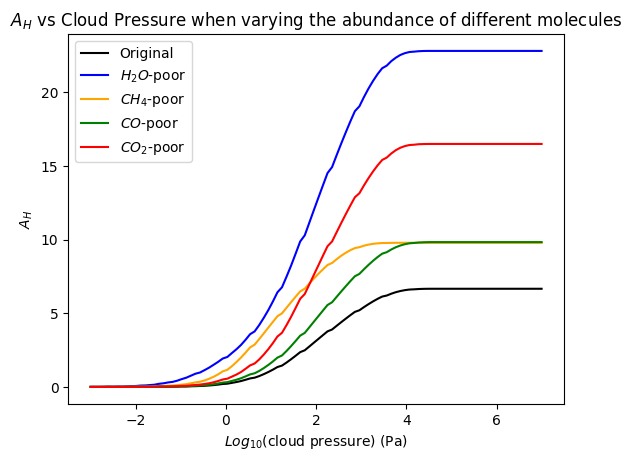

In [11]:
# plt.plot(np.log10(pval_original), A_H_original, linestyle='-', color='black', label="Original", marker='*')
# plt.plot(np.log10(pval_H2O), A_H_H2O, linestyle='-', color='blue', label="H2O-poor", marker='+')
# plt.plot(np.log10(pval_CH4), A_H_CH4, linestyle='-', color='orange', label="CH4-poor", marker='x')
# plt.plot(np.log10(pval_CO), A_H_CO, linestyle='-', color='green', label="CO-poor", marker='1')
# plt.plot(np.log10(pval_CO2), A_H_CO2, linestyle='-', color='red', label="CO2-poor", marker='^')

plt.plot(np.log10(pval_original), A_H_original, linestyle='-', color='black', label="Original")
plt.plot(np.log10(pval_H2O), A_H_H2O, linestyle='-', color='blue', label="$H_{2}O$-poor")
plt.plot(np.log10(pval_CH4), A_H_CH4, linestyle='-', color='orange', label="$CH_{4}$-poor")
plt.plot(np.log10(pval_CO), A_H_CO, linestyle='-', color='green', label="$CO$-poor")
plt.plot(np.log10(pval_CO2), A_H_CO2, linestyle='-', color='red', label="$CO_{2}$-poor")

plt.xlabel('$Log_{10}$(cloud pressure) (Pa)')
plt.ylabel("$A_{H}$")
plt.title('$A_{H}$ vs Cloud Pressure when varying the abundance of different molecules')
plt.legend()
plt.show()

In [10]:
max_index = np.argmax(A_H_original)
pval_at_max_AH = pval_original[max_index]
print('A_H original max:', max(A_H_original), ', Pval at max A_H for original:', np.log10(pval_at_max_AH))

max_index = np.argmax(A_H_H2O)
pval_at_max_AH = pval_H2O[max_index]
print('A_H H2O-poor max:', max(A_H_H2O), ', Pval at max A_H for H2O-poor:', np.log10(pval_at_max_AH))

max_index = np.argmax(A_H_CH4)
pval_at_max_AH = pval_CH4[max_index]
print('A_H CH4-poor max:', max(A_H_CH4), ', Pval at max A_H for CH4-poor:', np.log10(pval_at_max_AH))

max_index = np.argmax(A_H_CO)
pval_at_max_AH = pval_CO[max_index]
print('A_H CO-poor max:', max(A_H_CO), ', Pval at max A_H for CO-poor:', np.log10(pval_at_max_AH))

max_index = np.argmax(A_H_CO2)
pval_at_max_AH = pval_CO2[max_index]
print('A_H CO2-poor max:', max(A_H_CO2), ', Pval at max A_H for CO2-poor:', np.log10(pval_at_max_AH))

A_H original max: 6.6648156602652415 , Pval at max A_H for original: 4.575757575757575
A_H H2O-poor max: 22.81346003152561 , Pval at max A_H for H2O-poor: 4.474747474747475
A_H CH4-poor max: 9.786515280788365 , Pval at max A_H for CH4-poor: 3.8686868686868685
A_H CO-poor max: 9.832202206901146 , Pval at max A_H for CO-poor: 4.575757575757575
A_H CO2-poor max: 16.49739433875208 , Pval at max A_H for CO2-poor: 4.575757575757575
